In [16]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import tqdm
import math
import warnings
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

%aimport Sub
%aimport Master
%aimport DataPreparation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
def retract(var, r, c):
    dir = var - c
    dir_norm = np.linalg.norm(dir)
    var_new = r * dir /dir_norm + c
    return var_new

In [2]:
class fxy:
    def __init__(self, MIP=False):
        env = gp.Env()
        env.setParam('OutputFlag', 0)
        self.model = gp.Model(env=env)
        if MIP:
            self.x = self.model.addMVar(2, vtype=GRB.BINARY, name='x')
        else:
            self.x = self.model.addMVar(2,  ub=10, name='x')
        self.y = self.model.addMVar(2, ub= 4, vtype=GRB.CONTINUOUS, name='y')
        self.constr = self.model.addConstr(self.x[0] - self.x[1] + self.y[0] + 2*self.y[1] >= 4, name='constr')
        self.fixed_obj = 5*self.x[0] - self.x[1] + 2*self.y[0] - 3*self.y[1]
        self.model.setObjective(self.fixed_obj, sense=GRB.MINIMIZE)
        self.model.update()

In [116]:
# Microgrids data
from DataPreparation import getMGData
mg_id = 0
n_mgs = 3
horizon_len = 24
data = getMGData(n_mgs, mg_id, horizon_len)[0]

In [31]:
from Sub import Sub
f = fxy(False)#Sub(data=data, trade=True, MIP=False)
n = len(f.x.tolist())
l = np.zeros(n)
z = np.zeros(n)
c = 0.5 * np.ones(n)
r = math.sqrt(n) / 2
rho = 0.001
gamma = 10
eta = 0.01
k = 100
a = 0.09

Q0 = lambda x: 1 / (1 + math.e**(k*(x+a)))
Q1 = lambda x: 1 / (1 + math.e**(-k*(x-a-1)))
Gg = lambda x: gamma * (Q0(x)**2 - Q1(x)**2 - Q0(x) + Q1(x))

done = False
itr = 0
max_itr = 1000
res_p, res_d = [], []
eps = 0.0001

Set parameter Username
Set parameter LicenseID to value 2625858
Academic license - for non-commercial use only - expires 2026-02-20


In [32]:
for itr in tqdm.tqdm(range(max_itr)):
    # solve f
    x = np.array(f.x.tolist())
    diff = x - z
    var_obj = l.T * diff + 0.5 * rho * diff.T * diff
    f.model.setObjective(f.fixed_obj + var_obj.sum(), sense=GRB.MINIMIZE)
    f.model.optimize()
    x_new = f.x.x
    # solve for z
    G_1 = -l - rho * (x_new - z)
    G_2 = Gg(x_new)
    G = G_1 + G_2
    v = z - c
    vvT = v * v.T
    vvT_unit = vvT / (r ** 2)
    vvTG = vvT_unit @ G
    grad_G = G - vvTG
    z_new = z - eta * grad_G
    z_new = retract(z_new, r, c)
    # update l
    l_new = l + rho * (x_new - z_new)
    # residual
    r_p = np.linalg.norm(x_new - z_new)
    r_d = np.linalg.norm(rho * (z_new - z))
    res_p.append(r_p)
    res_d.append(r_d)
    # terminate
    done = r_p + r_d <= eps
    # iterate
    z = z_new
    l = l_new
    itr += 1
    if done:
        break

print(f'Finished in {itr}/{max_itr} iterations')

 49%|████▉     | 490/1000 [00:00<00:00, 565.38it/s]

Finished in 491/1000 iterations


In [34]:
np.round(x_new, decimals=3)

array([0., 1.])

In [33]:
np.round(z, decimals=3)

array([-0.,  1.])

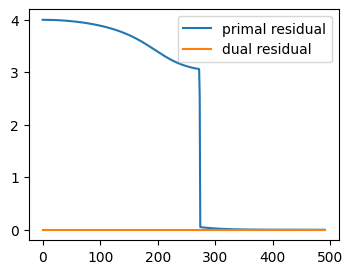

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))
plt.plot(res_p, label='primal residual')
plt.plot(res_d, label='dual residual')
plt.legend()

In [37]:
bench = fxy(True)
bench.model.optimize()
print(bench.x.x, bench.model.ObjVal)

Set parameter Username
Set parameter LicenseID to value 2625858
Academic license - for non-commercial use only - expires 2026-02-20
[0. 1.] -13.0


In [115]:
bench.model.ObjVal

-0.43421469562393944